<a href="https://colab.research.google.com/github/wytcher28/Mestrado/blob/main/Mestrado_Treinamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

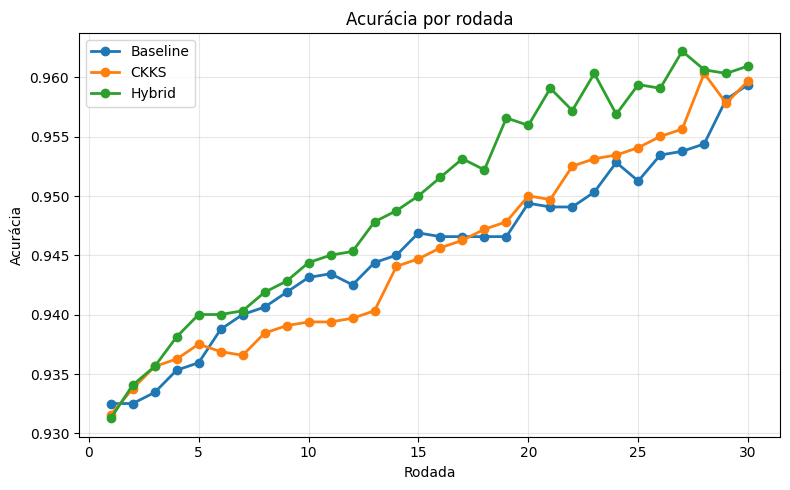

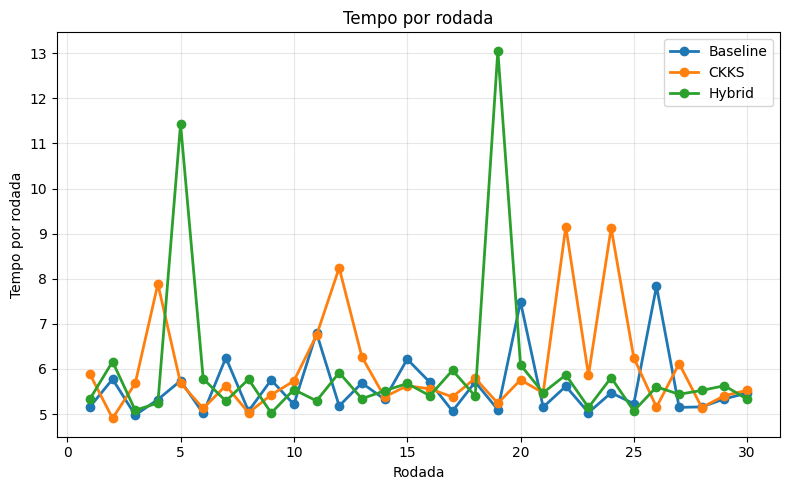

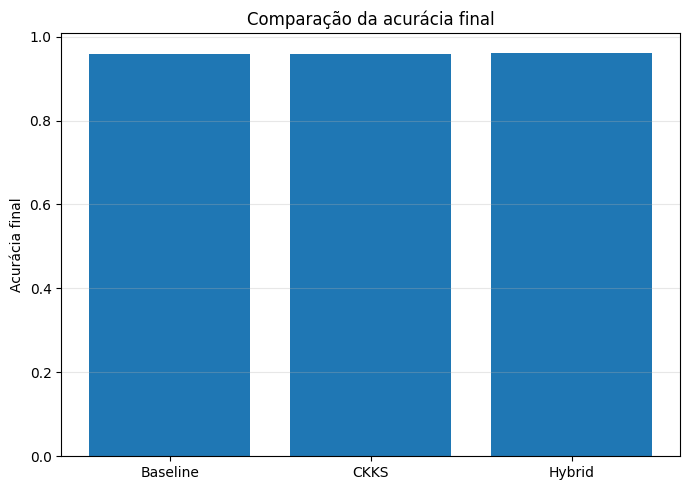

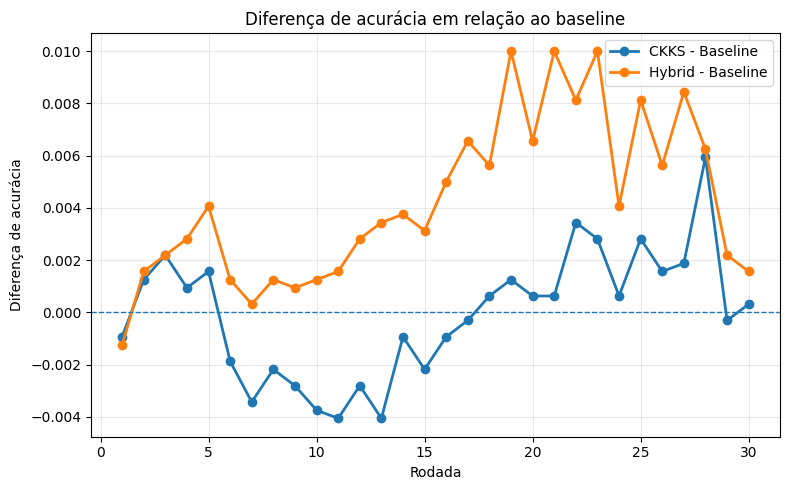

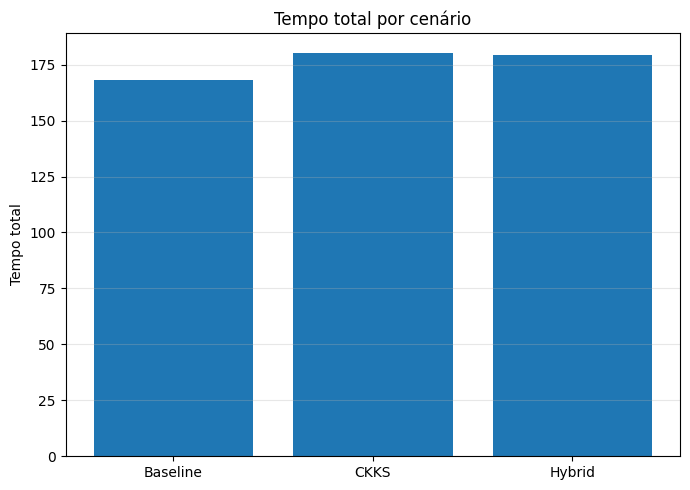

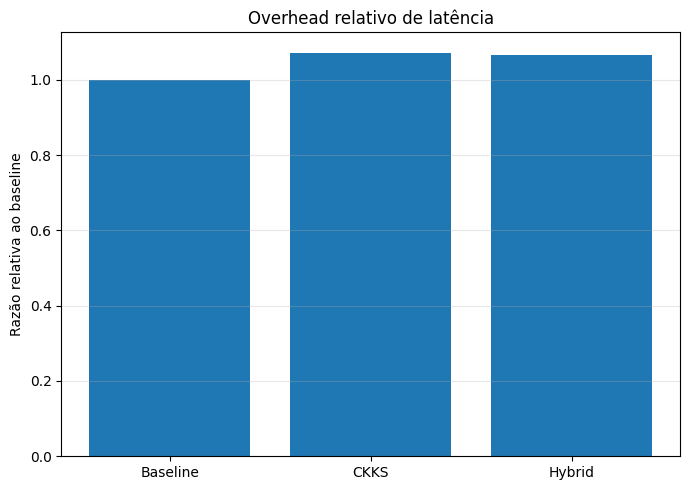

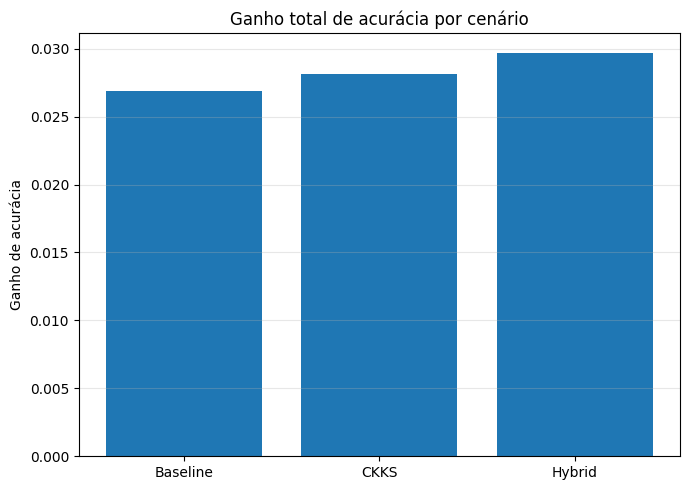

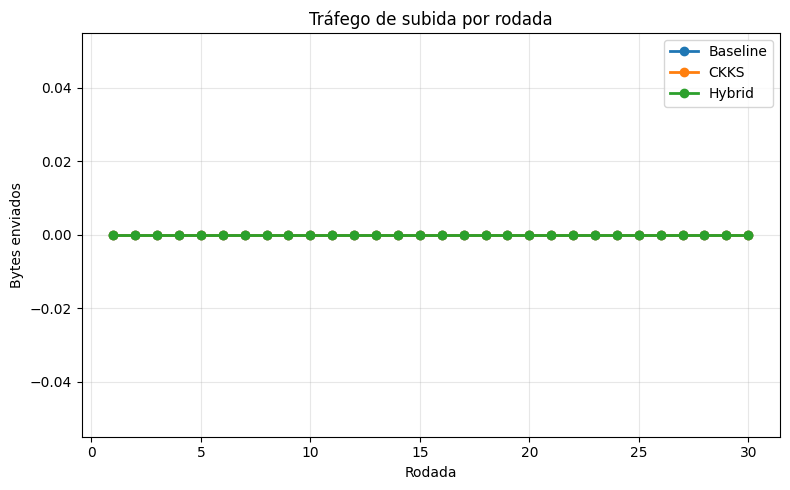

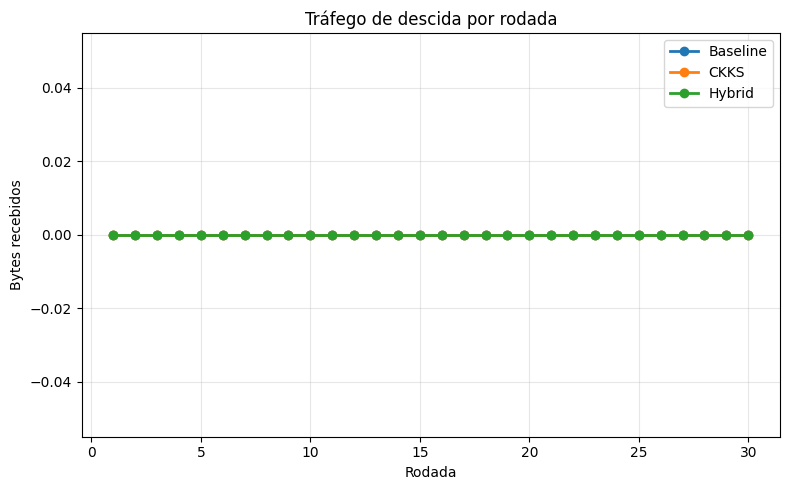

    cenario  acuracia_inicial  acuracia_final  ganho_acuracia  tempo_medio  \
0  Baseline          0.932521        0.959388        0.026867     5.600382   
1      CKKS          0.931584        0.959700        0.028116     6.006980   
2    Hybrid          0.931271        0.960950        0.029678     5.974515   

   tempo_total  
0   168.011454  
1   180.209405  
2   179.235457  

Figuras salvas em: /content/drive/MyDrive/Mestrado_Resultados/figures_cap4


In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CAMINHOS DOS RESULTADOS
# =========================
base = "/content/drive/MyDrive/Mestrado_Resultados"

baseline_path = f"{base}/baseline_20260331_144753/rounds.csv"
ckks_path    = f"{base}/ckks_20260331_145333/rounds.csv"
hybrid_path  = f"{base}/hybrid_20260331_145909/rounds.csv"

baseline = pd.read_csv(baseline_path)
ckks = pd.read_csv(ckks_path)
hybrid = pd.read_csv(hybrid_path)

# pasta de saída das figuras
fig_dir = "/content/drive/MyDrive/Mestrado_Resultados/figures_cap4"
os.makedirs(fig_dir, exist_ok=True)

# =========================
# AJUSTE DE NOMES DE COLUNA
# =========================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Nenhuma das colunas {candidates} encontrada. Colunas disponíveis: {list(df.columns)}")

round_col = pick_col(baseline, ["round"])
acc_col = pick_col(baseline, ["accuracy", "val_accuracy"])
time_col = pick_col(baseline, ["round_time", "latency_round_ms"])
f1_col = pick_col(baseline, ["val_f1", "f1"]) if any(c in baseline.columns for c in ["val_f1", "f1"]) else None
auc_col = pick_col(baseline, ["val_auc", "auc"]) if any(c in baseline.columns for c in ["val_auc", "auc"]) else None
bytes_up_col = pick_col(baseline, ["bytes_client_to_B", "bytes_up"]) if any(c in baseline.columns for c in ["bytes_client_to_B", "bytes_up"]) else None
bytes_down_col = pick_col(baseline, ["bytes_B_to_A", "bytes_down"]) if any(c in baseline.columns for c in ["bytes_B_to_A", "bytes_down"]) else None

def rounds_axis(df):
    return df[round_col].values

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, name), dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 1. ACURÁCIA POR RODADA
# =========================
plt.figure(figsize=(8, 5))
plt.plot(rounds_axis(baseline), baseline[acc_col], marker="o", linewidth=2, label="Baseline")
plt.plot(rounds_axis(ckks), ckks[acc_col], marker="o", linewidth=2, label="CKKS")
plt.plot(rounds_axis(hybrid), hybrid[acc_col], marker="o", linewidth=2, label="Hybrid")
plt.xlabel("Rodada")
plt.ylabel("Acurácia")
plt.title("Acurácia por rodada")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("fig_4_1_acuracia_por_rodada.png")

# =========================
# 2. TEMPO POR RODADA
# =========================
plt.figure(figsize=(8, 5))
plt.plot(rounds_axis(baseline), baseline[time_col], marker="o", linewidth=2, label="Baseline")
plt.plot(rounds_axis(ckks), ckks[time_col], marker="o", linewidth=2, label="CKKS")
plt.plot(rounds_axis(hybrid), hybrid[time_col], marker="o", linewidth=2, label="Hybrid")
plt.xlabel("Rodada")
plt.ylabel("Tempo por rodada")
plt.title("Tempo por rodada")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("fig_4_2_tempo_por_rodada.png")

# =========================
# 3. ACURÁCIA FINAL
# =========================
labels = ["Baseline", "CKKS", "Hybrid"]
final_acc = [
    float(baseline[acc_col].iloc[-1]),
    float(ckks[acc_col].iloc[-1]),
    float(hybrid[acc_col].iloc[-1]),
]

plt.figure(figsize=(7, 5))
plt.bar(labels, final_acc)
plt.ylabel("Acurácia final")
plt.title("Comparação da acurácia final")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig_4_3_acuracia_final.png")

# =========================
# 4. DIFERENÇA DE ACURÁCIA VS BASELINE
# =========================
base_acc = baseline[acc_col].values
plt.figure(figsize=(8, 5))
plt.plot(rounds_axis(ckks), ckks[acc_col].values - base_acc, marker="o", linewidth=2, label="CKKS - Baseline")
plt.plot(rounds_axis(hybrid), hybrid[acc_col].values - base_acc, marker="o", linewidth=2, label="Hybrid - Baseline")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Rodada")
plt.ylabel("Diferença de acurácia")
plt.title("Diferença de acurácia em relação ao baseline")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("fig_4_4_diferenca_acuracia_vs_baseline.png")

# =========================
# 5. TEMPO TOTAL POR CENÁRIO
# =========================
total_time = [
    float(baseline[time_col].sum()),
    float(ckks[time_col].sum()),
    float(hybrid[time_col].sum()),
]

plt.figure(figsize=(7, 5))
plt.bar(labels, total_time)
plt.ylabel("Tempo total")
plt.title("Tempo total por cenário")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig_4_5_tempo_total_por_cenario.png")

# =========================
# 6. OVERHEAD RELATIVO VS BASELINE
# =========================
baseline_total = float(baseline[time_col].sum())
overhead = [
    1.0,
    float(ckks[time_col].sum()) / baseline_total,
    float(hybrid[time_col].sum()) / baseline_total,
]

plt.figure(figsize=(7, 5))
plt.bar(labels, overhead)
plt.ylabel("Razão relativa ao baseline")
plt.title("Overhead relativo de latência")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig_4_6_overhead_relativo.png")

# =========================
# 7. GANHO TOTAL DE ACURÁCIA
# =========================
gain_acc = [
    float(baseline[acc_col].iloc[-1] - baseline[acc_col].iloc[0]),
    float(ckks[acc_col].iloc[-1] - ckks[acc_col].iloc[0]),
    float(hybrid[acc_col].iloc[-1] - hybrid[acc_col].iloc[0]),
]

plt.figure(figsize=(7, 5))
plt.bar(labels, gain_acc)
plt.ylabel("Ganho de acurácia")
plt.title("Ganho total de acurácia por cenário")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig_4_7_ganho_total_acuracia.png")

# =========================
# 8. F1 POR RODADA (SE EXISTIR)
# =========================
if f1_col is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(rounds_axis(baseline), baseline[f1_col], marker="o", linewidth=2, label="Baseline")
    plt.plot(rounds_axis(ckks), ckks[f1_col], marker="o", linewidth=2, label="CKKS")
    plt.plot(rounds_axis(hybrid), hybrid[f1_col], marker="o", linewidth=2, label="Hybrid")
    plt.xlabel("Rodada")
    plt.ylabel("F1-score")
    plt.title("F1-score por rodada")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("fig_4_8_f1_por_rodada.png")

# =========================
# 9. AUC POR RODADA (SE EXISTIR)
# =========================
if auc_col is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(rounds_axis(baseline), baseline[auc_col], marker="o", linewidth=2, label="Baseline")
    plt.plot(rounds_axis(ckks), ckks[auc_col], marker="o", linewidth=2, label="CKKS")
    plt.plot(rounds_axis(hybrid), hybrid[auc_col], marker="o", linewidth=2, label="Hybrid")
    plt.xlabel("Rodada")
    plt.ylabel("AUC")
    plt.title("AUC por rodada")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("fig_4_9_auc_por_rodada.png")

# =========================
# 10. TRÁFEGO DE SUBIDA (SE EXISTIR)
# =========================
if bytes_up_col is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(rounds_axis(baseline), baseline[bytes_up_col], marker="o", linewidth=2, label="Baseline")
    plt.plot(rounds_axis(ckks), ckks[bytes_up_col], marker="o", linewidth=2, label="CKKS")
    plt.plot(rounds_axis(hybrid), hybrid[bytes_up_col], marker="o", linewidth=2, label="Hybrid")
    plt.xlabel("Rodada")
    plt.ylabel("Bytes enviados")
    plt.title("Tráfego de subida por rodada")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("fig_4_10_bytes_subida.png")

# =========================
# 11. TRÁFEGO DE DESCIDA (SE EXISTIR)
# =========================
if bytes_down_col is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(rounds_axis(baseline), baseline[bytes_down_col], marker="o", linewidth=2, label="Baseline")
    plt.plot(rounds_axis(ckks), ckks[bytes_down_col], marker="o", linewidth=2, label="CKKS")
    plt.plot(rounds_axis(hybrid), hybrid[bytes_down_col], marker="o", linewidth=2, label="Hybrid")
    plt.xlabel("Rodada")
    plt.ylabel("Bytes recebidos")
    plt.title("Tráfego de descida por rodada")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("fig_4_11_bytes_descida.png")

# =========================
# TABELA-RESUMO
# =========================
summary = pd.DataFrame([
    {
        "cenario": "Baseline",
        "acuracia_inicial": float(baseline[acc_col].iloc[0]),
        "acuracia_final": float(baseline[acc_col].iloc[-1]),
        "ganho_acuracia": float(baseline[acc_col].iloc[-1] - baseline[acc_col].iloc[0]),
        "tempo_medio": float(baseline[time_col].mean()),
        "tempo_total": float(baseline[time_col].sum()),
    },
    {
        "cenario": "CKKS",
        "acuracia_inicial": float(ckks[acc_col].iloc[0]),
        "acuracia_final": float(ckks[acc_col].iloc[-1]),
        "ganho_acuracia": float(ckks[acc_col].iloc[-1] - ckks[acc_col].iloc[0]),
        "tempo_medio": float(ckks[time_col].mean()),
        "tempo_total": float(ckks[time_col].sum()),
    },
    {
        "cenario": "Hybrid",
        "acuracia_inicial": float(hybrid[acc_col].iloc[0]),
        "acuracia_final": float(hybrid[acc_col].iloc[-1]),
        "ganho_acuracia": float(hybrid[acc_col].iloc[-1] - hybrid[acc_col].iloc[0]),
        "tempo_medio": float(hybrid[time_col].mean()),
        "tempo_total": float(hybrid[time_col].sum()),
    },
])

summary.to_csv(os.path.join(fig_dir, "tabela_resumo_cap4.csv"), index=False)
print(summary)
print(f"\nFiguras salvas em: {fig_dir}")